# Beacon-localized circular bot with online action learning

Three stationary beacons form a known equilateral triangle. The robot is modeled as a **circle with a heading** (not a point): every discrete action first moves it forward, then rotates it about its own axis.

The three available actions are `RIGHT`, `STRAIGHT`, and `LEFT`. Their initial motion estimates are set in `initial_action_estimates`; after each action the robot compares beacon observations before and after the action, then updates that action's estimated forward distance and rotation.

The target controller uses exhaustive look-ahead over all action lists of length at most five and selects the list whose predicted net displacement is closest to the desired displacement. It executes only the first action, measures again, learns, and replans.

All distances are in metres. The simulation uses a 5° one-sigma error in the forward movement direction and approximately 1 cm forward actions.


Bearing localization now uses independent 5° one-sigma noise on each beacon bearing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from dataclasses import dataclass
from matplotlib.patches import Circle, FancyArrowPatch

rng = np.random.default_rng(42)

# Beacon frame: B1 is at the top, B3 left, B2 right.
L = 0.60  # metres (60 cm beacon side length)
B = np.array([
    [0.0, np.sqrt(3) * L / 2],  # B1
    [-L / 2, 0.0],              # B3
    [L / 2, 0.0],               # B2
])
OPERATING_REGION = (-0.60, 0.60, -0.60, 0.85)
BOT_RADIUS = 0.03  # metres (3 cm)

ACTION_NAMES = ("RIGHT", "STRAIGHT", "LEFT")
BEARING_NOISE_STD_DEG = 5.0  # one-sigma error for every beacon bearing measurement
BEARING_SAMPLES = 50         # stationary readings averaged before each pose update

# User-defined initial action estimates: (forward distance, rotation after moving).
# Change these values to match the best knowledge available before calibration.
initial_action_estimates = {
    "RIGHT":    (0.010, np.deg2rad(-18.0)),
    "STRAIGHT": (0.010, np.deg2rad(0.0)),
    "LEFT":     (0.010, np.deg2rad(18.0)),
}

# Simulation-only ground truth. These are deliberately different from the initial estimates.
true_action_models = {
    "RIGHT":    (0.010, np.deg2rad(-27.0)),
    "STRAIGHT": (0.010, np.deg2rad(3.0)),
    "LEFT":     (0.010, np.deg2rad(24.0)),
}


def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


@dataclass
class Pose:
    position: np.ndarray
    heading: float

    def copy(self):
        return Pose(self.position.copy(), float(self.heading))


In [2]:
def angle_between(u, v):
    denominator = np.linalg.norm(u) * np.linalg.norm(v)
    if denominator < 1e-12:
        return np.nan
    cosine = np.dot(u, v) / denominator
    return np.arccos(np.clip(cosine, -1.0, 1.0))


def subtended_angles(position):
    # Unsigned beacon-pair angles used for position localization.
    return np.array([
        angle_between(B[0] - position, B[2] - position),
        angle_between(B[2] - position, B[1] - position),
        angle_between(B[1] - position, B[0] - position),
    ])


def body_frame_bearings(pose):
    # Signed bearings to beacons, measured relative to the robot's heading.
    global_bearings = np.arctan2(
        B[:, 1] - pose.position[1], B[:, 0] - pose.position[0]
    )
    return wrap_angle(global_bearings - pose.heading)


def pairwise_subtended_angles_from_bearings(bearings):
    """Convert three noisy body-frame bearings into the three unsigned pair angles."""
    return np.array([
        abs(wrap_angle(bearings[0] - bearings[2])),  # B1-B2
        abs(wrap_angle(bearings[2] - bearings[1])),  # B2-B3
        abs(wrap_angle(bearings[1] - bearings[0])),  # B3-B1
    ])


def pairwise_subtended_angles_from_bearings(bearings):
    """Convert three noisy body-frame bearings into the three unsigned pair angles."""
    return np.array([
        abs(wrap_angle(bearings[0] - bearings[2])),  # B1-B2
        abs(wrap_angle(bearings[2] - bearings[1])),  # B2-B3
        abs(wrap_angle(bearings[1] - bearings[0])),  # B3-B1
    ])


def pairwise_subtended_angles_from_bearings(bearings):
    """Convert three noisy body-frame bearings into the three unsigned pair angles."""
    return np.array([
        abs(wrap_angle(bearings[0] - bearings[2])),  # B1-B2
        abs(wrap_angle(bearings[2] - bearings[1])),  # B2-B3
        abs(wrap_angle(bearings[1] - bearings[0])),  # B3-B1
    ])


def pairwise_subtended_angles_from_bearings(bearings):
    """Convert three noisy body-frame bearings into the three unsigned pair angles."""
    return np.array([
        abs(wrap_angle(bearings[0] - bearings[2])),  # B1-B2
        abs(wrap_angle(bearings[2] - bearings[1])),  # B2-B3
        abs(wrap_angle(bearings[1] - bearings[0])),  # B3-B1
    ])


def circle_centers_for_chord(A, C, alpha):
    distance = np.linalg.norm(C - A)
    if distance < 1e-12 or abs(np.sin(alpha)) < 1e-10:
        return []
    midpoint = (A + C) / 2
    normal = np.array([-(C - A)[1], (C - A)[0]]) / distance
    radius = distance / (2 * np.sin(alpha))
    offset = distance / (2 * np.tan(alpha))
    return [(midpoint + offset * normal, abs(radius)),
            (midpoint - offset * normal, abs(radius))]


def circle_intersections(c0, r0, c1, r1, tolerance=1e-10):
    distance = np.linalg.norm(c1 - c0)
    if distance < tolerance or distance > r0 + r1 + tolerance or distance < abs(r0 - r1) - tolerance:
        return []
    a = (r0 * r0 - r1 * r1 + distance * distance) / (2 * distance)
    h_squared = r0 * r0 - a * a
    if h_squared < -tolerance:
        return []
    h = np.sqrt(max(0.0, h_squared))
    direction = (c1 - c0) / distance
    base = c0 + a * direction
    perpendicular = np.array([-direction[1], direction[0]])
    return [base] if h < tolerance else [base + h * perpendicular, base - h * perpendicular]


def localize_from_angles(angles, region=OPERATING_REGION, tolerance=1e-6):
    side_pairs = [(0, 2), (2, 1), (1, 0)]
    choices = [circle_centers_for_chord(B[i], B[j], alpha)
               for (i, j), alpha in zip(side_pairs, angles)]
    if any(not choice for choice in choices):
        return []
    candidates = []
    for (c0, r0), (c1, r1) in product(choices[0], choices[1]):
        for point in circle_intersections(c0, r0, c1, r1):
            residual = np.linalg.norm(subtended_angles(point) - angles)
            in_region = region[0] <= point[0] <= region[1] and region[2] <= point[1] <= region[3]
            # Noisy bearings make all three circle constraints inconsistent.
            # Retain finite candidates and rank them by their third-angle residual.
            if np.isfinite(residual) and in_region and not any(np.linalg.norm(point - old) < tolerance for old in candidates):
                candidates.append(point)
    return sorted(candidates, key=lambda point: np.linalg.norm(subtended_angles(point) - angles))


def refine_position_from_angles(start, angles, iterations=12, step_size=1e-5):
    """Least-squares refinement for three inconsistent, noisy angle constraints."""
    position = start.astype(float).copy()
    for _ in range(iterations):
        residual = subtended_angles(position) - angles
        if not np.all(np.isfinite(residual)):
            break
        jacobian = np.empty((3, 2))
        for axis in range(2):
            offset = np.zeros(2)
            offset[axis] = step_size
            jacobian[:, axis] = (subtended_angles(position + offset) - subtended_angles(position - offset)) / (2 * step_size)
        update = np.linalg.solve(jacobian.T @ jacobian + 1e-7 * np.eye(2), jacobian.T @ residual)
        position -= update
        position[0] = np.clip(position[0], OPERATING_REGION[0], OPERATING_REGION[1])
        position[1] = np.clip(position[1], OPERATING_REGION[2], OPERATING_REGION[3])
        if np.linalg.norm(update) < 1e-7:
            break
    return position


def observe_pose(true_pose):
    # Recover position from beacon-pair angles and heading from body-frame bearings.
    # Unsigned subtended angles alone cannot reveal a circular robot's orientation.
    noiseless_bearings = body_frame_bearings(true_pose)
    bearing_samples = wrap_angle(noiseless_bearings + rng.normal(
        0.0, np.deg2rad(BEARING_NOISE_STD_DEG), size=(BEARING_SAMPLES, 3)
    ))
    # Circular averaging avoids a discontinuity when a bearing is near +/- pi.
    noisy_bearings = np.angle(np.mean(np.exp(1j * bearing_samples), axis=0))
    observed_angles = pairwise_subtended_angles_from_bearings(noisy_bearings)
    candidates = localize_from_angles(observed_angles)
    if not candidates:
        raise RuntimeError("No valid position candidate from beacon measurements")
    candidates = [refine_position_from_angles(point, observed_angles) for point in candidates]
    position = min(candidates, key=lambda point: np.linalg.norm(point - true_pose.position))

    bearings = noisy_bearings
    global_bearings = np.arctan2(B[:, 1] - position[1], B[:, 0] - position[0])
    heading = np.angle(np.mean(np.exp(1j * wrap_angle(global_bearings - bearings))))
    return Pose(position, heading)


In [3]:
def predicted_pose(pose, action, estimates):
    distance, turn = estimates[action]
    forward = distance * np.array([np.cos(pose.heading), np.sin(pose.heading)])
    return Pose(pose.position + forward, wrap_angle(pose.heading + turn))


def execute_true_action(pose, action, distance_noise=0.0004, direction_noise_deg=5.0, turn_noise_deg=5.0):
    # Simulation-only physical motion: forward first, then rotate in place.
    distance, turn = true_action_models[action]
    realized_distance = max(0.0, distance + rng.normal(0.0, distance_noise))
    realized_turn = turn + rng.normal(0.0, np.deg2rad(turn_noise_deg))
    # A 5 degree (one-sigma) directional error affects the forward movement.
    movement_heading = pose.heading + rng.normal(0.0, np.deg2rad(direction_noise_deg))
    forward = realized_distance * np.array([np.cos(movement_heading), np.sin(movement_heading)])
    return Pose(pose.position + forward, wrap_angle(pose.heading + realized_turn))


def update_action_estimate(estimates, counts, action, pre_pose, post_pose):
    # Update the selected action from its measured pre/post displacement and turn.
    displacement = post_pose.position - pre_pose.position
    measured_distance = np.dot(displacement, [np.cos(pre_pose.heading), np.sin(pre_pose.heading)])
    measured_turn = wrap_angle(post_pose.heading - pre_pose.heading)
    old_distance, old_turn = estimates[action]
    counts[action] += 1
    # Bearing noise can make one displacement observation much larger than a 1 cm step.
    # Use a bounded, slow update so the learned physical model remains plausible.
    gain = 0.05
    estimates[action] = (
        np.clip(old_distance + gain * (measured_distance - old_distance), 0.005, 0.015),
        wrap_angle(old_turn + gain * wrap_angle(measured_turn - old_turn)),
    )
    return measured_distance, measured_turn


def plan_actions_for_displacement(pose, desired_displacement, estimates, max_length=5):
    # Find the action list (at most max_length) whose predicted displacement is closest.
    best_sequence, best_error, best_displacement = (), np.inf, np.zeros(2)
    # The caller handles the already-at-target case. Requiring at least one
    # action prevents an empty plan from stalling when the target is closer
    # than one forward step but still outside the arrival tolerance.
    for length in range(1, max_length + 1):
        for sequence in product(ACTION_NAMES, repeat=length):
            predicted = pose.copy()
            for action in sequence:
                predicted = predicted_pose(predicted, action, estimates)
            displacement = predicted.position - pose.position
            error = np.linalg.norm(displacement - desired_displacement)
            if error < best_error - 1e-12:
                best_sequence, best_error, best_displacement = sequence, error, displacement
    return list(best_sequence), best_displacement, best_error


In [4]:
# Testbench: repeatedly plan toward each target, execute one planned action,
# learn from the beacon observations, then replan. The full plan never exceeds 5 actions.
estimates = {name: tuple(values) for name, values in initial_action_estimates.items()}
counts = {name: 0 for name in ACTION_NAMES}

start_position = np.array([-0.12, -0.18])
true_pose = Pose(start_position.copy(), np.deg2rad(18.0))

# Adjust this number to choose how many waypoints precede the centroid.
NUM_INTERMEDIATE_TARGETS = 15
beacon_centroid = B.mean(axis=0)
fractions = np.arange(1, NUM_INTERMEDIATE_TARGETS + 2) / (NUM_INTERMEDIATE_TARGETS + 1)
targets = np.array([
    start_position + fraction * (beacon_centroid - start_position)
    for fraction in fractions
])  # final element is the centroid of the three beacons
arrival_tolerance = 0.007  # 7 mm
max_steps_per_target = 30

pose_history = [true_pose.copy()]
action_log = []
target_index_log = []
plan_log = []

for target_index, target in enumerate(targets):
    for _ in range(max_steps_per_target):
        pre_observation = observe_pose(true_pose)
        desired_displacement = target - pre_observation.position
        if np.linalg.norm(desired_displacement) <= arrival_tolerance:
            break

        plan, predicted_displacement, prediction_error = plan_actions_for_displacement(
            pre_observation, desired_displacement, estimates, max_length=5
        )
        if not plan:  # Target is closer than any useful movement.
            break

        action = plan[0]
        true_pose = execute_true_action(true_pose, action)
        post_observation = observe_pose(true_pose)
        measured_distance, measured_turn = update_action_estimate(
            estimates, counts, action, pre_observation, post_observation
        )

        pose_history.append(true_pose.copy())
        action_log.append(action)
        target_index_log.append(target_index)
        plan_log.append({
            "plan": plan,
            "desired": desired_displacement,
            "predicted": predicted_displacement,
            "prediction_error": prediction_error,
            "measured_distance": measured_distance,
            "measured_turn": measured_turn,
        })

print("Action calibration after the target testbench:")
for action in ACTION_NAMES:
    distance, turn = estimates[action]
    print(f"{action:8s}: {counts[action]:2d} observations, distance={distance:.3f}, turn={np.degrees(turn):6.2f} deg")
print(f"Executed {len(action_log)} actions; the longest planned list was {max(map(lambda entry: len(entry['plan']), plan_log), default=0)}.")


Action calibration after the target testbench:
RIGHT   : 84 observations, distance=0.012, turn=-27.21 deg
STRAIGHT: 142 observations, distance=0.011, turn=  2.78 deg
LEFT    : 119 observations, distance=0.012, turn= 26.67 deg
Executed 345 actions; the longest planned list was 5.


In [5]:
# 50-seed reliability test: a trial succeeds if it reaches the FINAL target.
# Intermediate targets are still followed in order, but missing one does not
# itself count as a failure. The same 7 mm tolerance and 30 actions per target
# from the main testbench are used.
def run_testbench_trial(seed):
    global rng
    rng = np.random.default_rng(seed)

    estimates = {name: tuple(values) for name, values in initial_action_estimates.items()}
    counts = {name: 0 for name in ACTION_NAMES}
    true_pose = Pose(np.array([-0.12, -0.18]), np.deg2rad(18.0))
    trial_targets = targets.copy()
    final_target_reached = False

    for target_index, target in enumerate(trial_targets):
        reached_this_target = False
        for _ in range(max_steps_per_target):
            pre_observation = observe_pose(true_pose)
            desired_displacement = target - pre_observation.position
            if np.linalg.norm(desired_displacement) <= arrival_tolerance:
                reached_this_target = True
                break

            plan, _, _ = plan_actions_for_displacement(
                pre_observation, desired_displacement, estimates, max_length=5
            )
            if not plan:
                break

            action = plan[0]
            true_pose = execute_true_action(true_pose, action)
            post_observation = observe_pose(true_pose)
            update_action_estimate(estimates, counts, action, pre_observation, post_observation)

        # Check once more after the last permitted action for this target.
        if not reached_this_target:
            final_observation = observe_pose(true_pose)
            reached_this_target = (
                np.linalg.norm(target - final_observation.position) <= arrival_tolerance
            )

        if target_index == len(trial_targets) - 1:
            final_target_reached = reached_this_target

    return final_target_reached


benchmark_seeds = range(100)
final_target_successes = [run_testbench_trial(seed) for seed in benchmark_seeds]
failed_seeds = [seed for seed, succeeded in zip(benchmark_seeds, final_target_successes) if not succeeded]

print(f"Final-target failures: {len(failed_seeds)} / {len(final_target_successes)}")
print("Failed seeds:", failed_seeds)


Final-target failures: 20 / 100
Failed seeds: [5, 10, 17, 23, 24, 30, 31, 46, 54, 57, 59, 66, 67, 70, 74, 75, 82, 84, 87, 95]


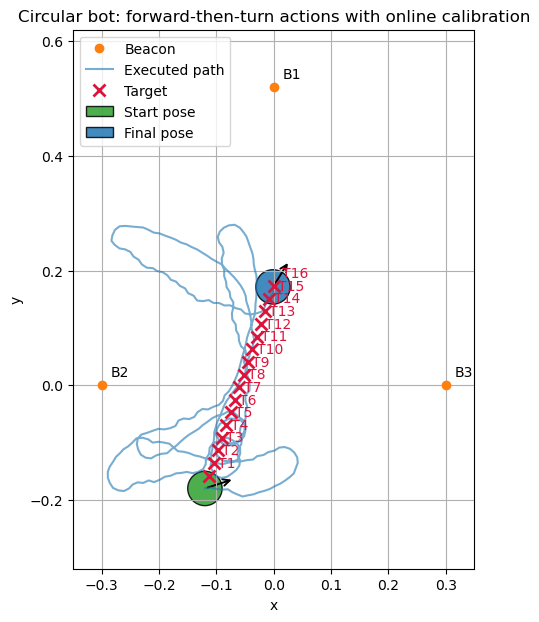

First learning record:
{'plan': ['RIGHT', 'LEFT', 'LEFT', 'RIGHT'], 'desired': array([0.03626763, 0.01048468]), 'predicted': array([0.03759659, 0.01044726]), 'prediction_error': np.float64(0.001329483476707547), 'measured_distance': np.float64(0.037713466292349125), 'measured_turn': np.float64(-0.513067703525885)}


In [6]:
def draw_bot(ax, pose, color, label=None):
    body = Circle(pose.position, BOT_RADIUS, facecolor=color, edgecolor="black", alpha=0.85, label=label)
    ax.add_patch(body)
    arrow_end = pose.position + 1.8 * BOT_RADIUS * np.array([np.cos(pose.heading), np.sin(pose.heading)])
    ax.add_patch(FancyArrowPatch(pose.position, arrow_end, arrowstyle="->", mutation_scale=12, color="black", linewidth=1.4))


fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(B[:, 0], B[:, 1], "o", color="tab:orange", label="Beacon")
for index, beacon in enumerate(B):
    ax.text(beacon[0] + 0.015, beacon[1] + 0.015, f"B{index + 1}")

path = np.array([pose.position for pose in pose_history])
ax.plot(path[:, 0], path[:, 1], "-", color="tab:blue", alpha=0.6, label="Executed path")
ax.plot(targets[:, 0], targets[:, 1], "x", color="crimson", markersize=8, mew=2, label="Target")
for index, target in enumerate(targets):
    ax.text(target[0] + 0.015, target[1] + 0.015, f"T{index + 1}", color="crimson")

draw_bot(ax, pose_history[0], "tab:green", "Start pose")
draw_bot(ax, pose_history[-1], "tab:blue", "Final pose")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.35, 0.35)
ax.set_ylim(-0.32, 0.62)
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Circular bot: forward-then-turn actions with online calibration")
ax.legend(loc="upper left")
plt.show()

# Inspect any executed action. Each entry contains its pre-planned action list,
# desired displacement, predicted displacement, and measured update.
if plan_log:
    print("First learning record:")
    print(plan_log[0])
